# Time Series

Выполнил: Немкова Анастасия Романовна

Описание столбцов: 
* `Store` - ID магазина.
* `Date` - дата на момент фиксации фич.
* `Weekly_Sales` - продажи за неделю.
* `Temperature` - средняя температура за неделю в городе расположения магазина(в градусах Фарингейта)
* `Fuel_Price` - цена топлива в данном регионе.
* `CPI` - индекс потребительских цен
* `Unemployment` - уровень безработици в регионе.

Цель - предсказать `Weekly_Sales` на 4 измерения вперед(на месяц).

Порог прохождения лабораторки - MAPE(%) - 10% (Score on leaderboard < 0.1)

In [334]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error
from statsmodels.tsa.seasonal import seasonal_decompose
from pylab import rcParams
from sklearn.model_selection import TimeSeriesSplit
from statsmodels.tsa.stattools import adfuller
import statsmodels.api as sm
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

import warnings
warnings.filterwarnings('ignore')

In [335]:
TRAIN_PATH = '/home/arnemkova/ML_labs/lab3/train.csv'
TEST_PATH = '/home/arnemkova/ML_labs/lab3/test.csv'

In [336]:
train_df = pd.read_csv(TRAIN_PATH, index_col=["Date"], parse_dates=["Date"])
test_df = pd.read_csv(TEST_PATH, index_col=["Date"], parse_dates=["Date"])
train_df.head()

,Store,Weekly_Sales,Temperature,Fuel_Price,CPI,Unemployment
Date,,,,,,
2010-01-10,1,1453329.50,71.89,2.603,211.671989,7.838
2010-02-04,1,1594968.28,62.27,2.719,210.820450,7.808
2010-02-07,1,1492418.14,80.91,2.669,211.223533,7.787
2010-02-19,1,1611968.17,39.93,2.514,211.289143,8.106
2010-02-26,1,1409727.59,46.63,2.561,211.319643,8.106


In [337]:
print(train_df.isnull().sum())
print(train_df.duplicated().sum())

Store           0
Weekly_Sales    0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
dtype: int64
0


In [338]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 6255 entries, 2010-01-10 to 2012-10-08
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6255 non-null   int64  
 1   Weekly_Sales  6255 non-null   float64
 2   Temperature   6255 non-null   float64
 3   Fuel_Price    6255 non-null   float64
 4   CPI           6255 non-null   float64
 5   Unemployment  6255 non-null   float64
dtypes: float64(5), int64(1)
memory usage: 342.1 KB


Посмотрим временной ряд целевой переменной

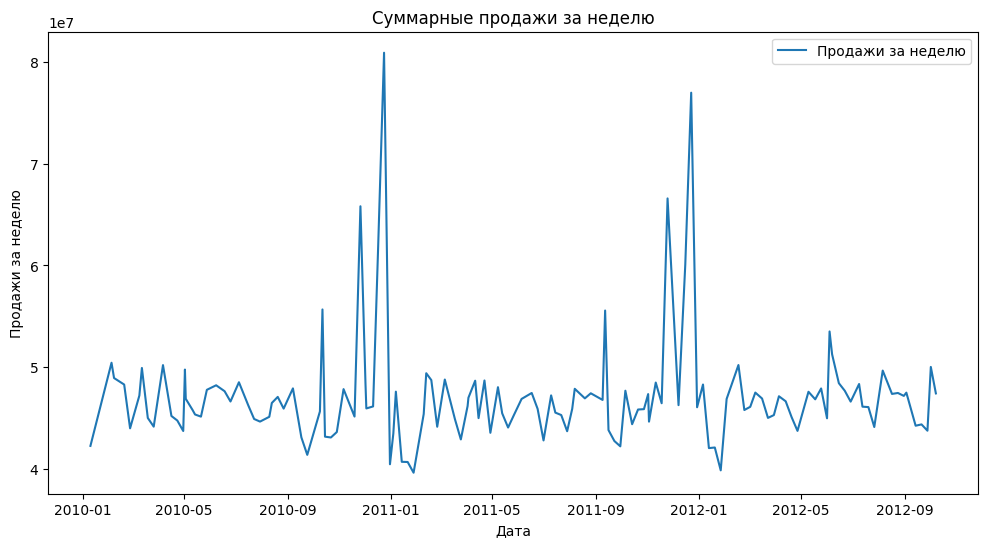

In [339]:
weekly_sales = train_df.groupby('Date')['Weekly_Sales'].sum()
plt.figure(figsize=(12, 6))
plt.plot(weekly_sales, label='Продажи за неделю')
plt.title("Суммарные продажи за неделю")
plt.xlabel("Дата")
plt.ylabel("Продажи за неделю")
plt.legend()
plt.show()

Видим, что наибольшие пики приходятся на конец года,начиная с октября месяца, и присутствуют резкие спады в начале каждого года

Посмотрим на зависимость `Weekly_Sales` от основных признаков на примере первого магазина

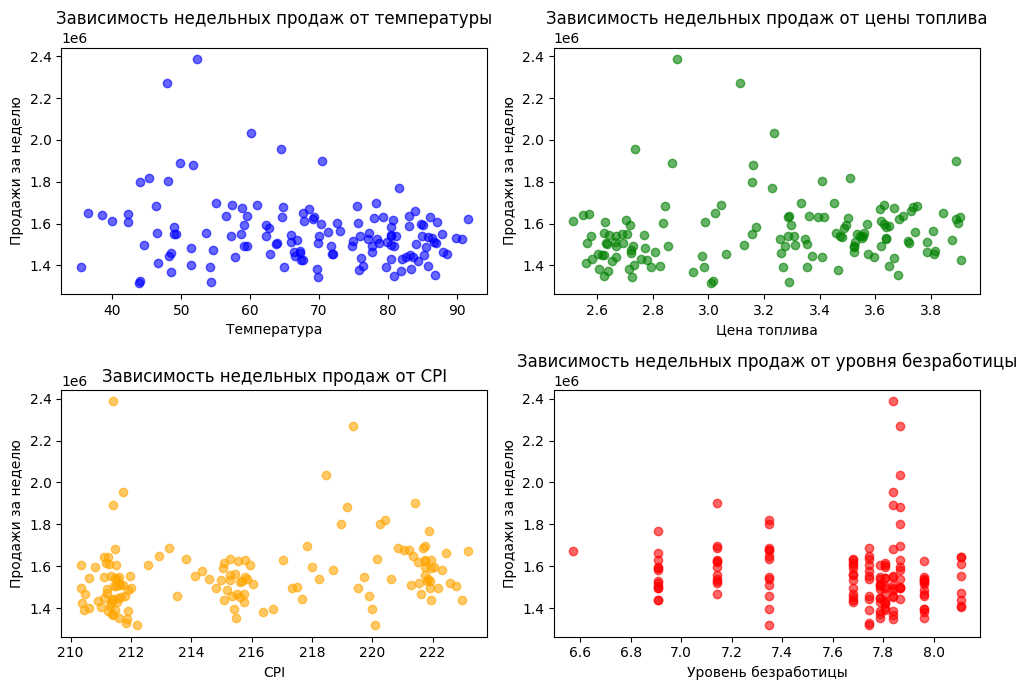

In [340]:
store_1_df = train_df[train_df['Store'] == 1]

plt.figure(figsize=(10, 7))
plt.subplot(2, 2, 1)
plt.scatter(store_1_df['Temperature'], store_1_df['Weekly_Sales'], color='blue', alpha=0.6)
plt.title("Зависимость недельных продаж от температуры")
plt.xlabel("Температура")
plt.ylabel('Продажи за неделю')

plt.subplot(2, 2, 2)
plt.scatter(store_1_df['Fuel_Price'], store_1_df['Weekly_Sales'], color='green', alpha=0.6)
plt.title("Зависимость недельных продаж от цены топлива")
plt.xlabel("Цена топлива")
plt.ylabel('Продажи за неделю')

plt.subplot(2, 2, 3)
plt.scatter(store_1_df['CPI'], store_1_df['Weekly_Sales'], color='orange', alpha=0.6)
plt.title("Зависимость недельных продаж от CPI")
plt.xlabel("CPI")
plt.ylabel('Продажи за неделю')

plt.subplot(2, 2, 4)
plt.scatter(store_1_df['Unemployment'], store_1_df['Weekly_Sales'], color='red', alpha=0.6)
plt.title("Зависимость недельных продаж от уровня безработицы")
plt.xlabel("Уровень безработицы")
plt.ylabel('Продажи за неделю')

plt.tight_layout()
plt.show()

Посмотрим на корреляционную матрицу

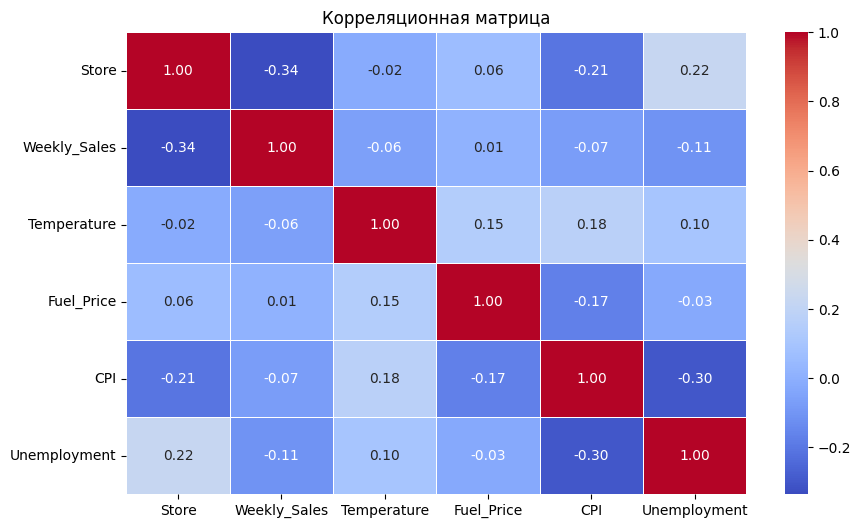

In [341]:
correlation_matrix = train_df.corr()
plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Корреляционная матрица')
plt.show()

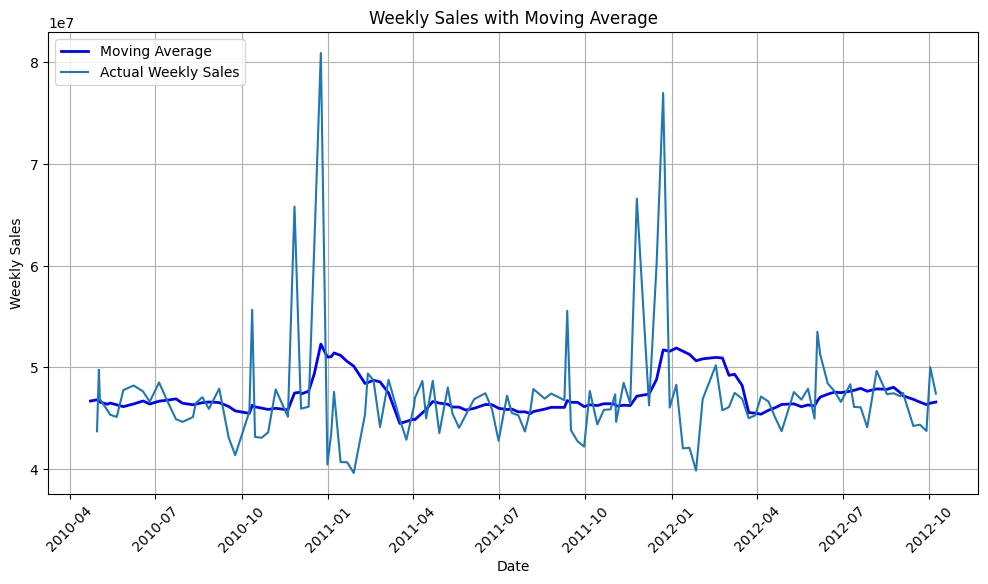

In [342]:
weekly_sales = train_df.groupby('Date')['Weekly_Sales'].sum()
rolling_data = weekly_sales.rolling(window=12).mean()
plt.figure(figsize=(12, 6))
plt.plot(rolling_data, label="Moving Average", color='blue', linewidth=2)
plt.plot(weekly_sales[12:], label="Actual Weekly Sales")
plt.title('Weekly Sales with Moving Average')
plt.xlabel('Date')
plt.ylabel('Weekly Sales')
plt.legend(loc='upper left')
plt.grid(True)
plt.xticks(rotation=45)
plt.show()

По графикам видим, что у `Weekly_Sales` нет особой зависимости от остальных признаков

Также видны небольшие подъёмы перед в конце года, что может говорить о годовой сезонности

Посмотрим на выбросы таргета

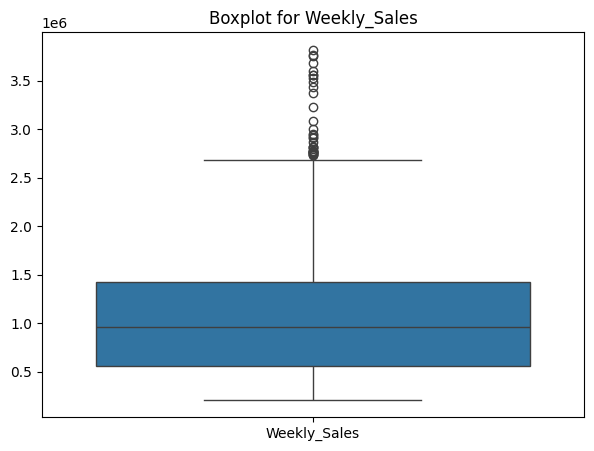

In [343]:
plt.figure(figsize=(7, 5))
sns.boxplot(data=train_df[['Weekly_Sales']])
plt.title('Boxplot for Weekly_Sales')
plt.show()

Почистим `Weekly_Sales` от выбросов

In [344]:
cleaned_data = []

for store_id, store_data in train_df.groupby('Store'):
    Q1 = store_data["Weekly_Sales"].quantile(0.25)
    Q3 = store_data["Weekly_Sales"].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR


    store_cleaned_data = store_data[(store_data["Weekly_Sales"] >= lower_bound) & (store_data["Weekly_Sales"] <= upper_bound)]
    
    cleaned_data.append(store_cleaned_data)

train_df = pd.concat(cleaned_data)

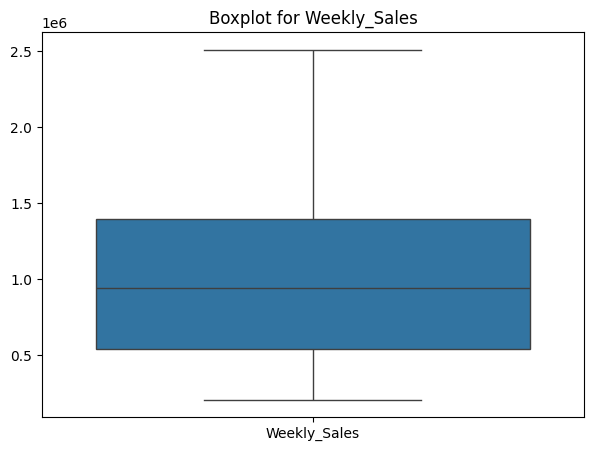

In [345]:
plt.figure(figsize=(7, 5))
sns.boxplot(data=train_df[['Weekly_Sales']])
plt.title('Boxplot for Weekly_Sales')
plt.show()

Преобразуем дату, выделим день недели, месяц, год и сезон

In [346]:
def add_time_features(df):
    df['Weekday'] = df.index.weekday 
    df['Month'] = df.index.month
    df['Year'] = df.index.year
    return df

train_df = add_time_features(train_df)
test_df = add_time_features(test_df)


In [347]:
def get_season(month):
    if month in [12, 1, 2]:
        return 1 
    elif month in [3, 4, 5]:
        return 2 
    elif month in [6, 7, 8]:
        return 3
    else:
        return 4
    
train_df['Season'] = train_df['Month'].apply(get_season)
test_df['Season'] = test_df['Month'].apply(get_season)

In [348]:
intervals = train_df[train_df['Store'] == 1].index.to_series().diff().value_counts()
print("Интервалы между записями:", intervals)

Интервалы между записями: Date
7 days     55
3 days     12
8 days     12
11 days     7
6 days      7
10 days     6
4 days      5
12 days     5
9 days      4
1 days      4
5 days      3
13 days     3
14 days     2
20 days     2
25 days     1
2 days      1
15 days     1
22 days     1
Name: count, dtype: int64


In [349]:
# store_dfs = []
# for store_id, df_store in train_df.groupby("Store"):
#     df_store = df_store.resample('W').mean()
#     df_store = df_store.interpolate(method='polynomial', order=2)
#     store_dfs.append(df_store)

# train_df = pd.concat(store_dfs)
# train_df.head()

Посмотрим на тренд, сезонность и случайные колебания

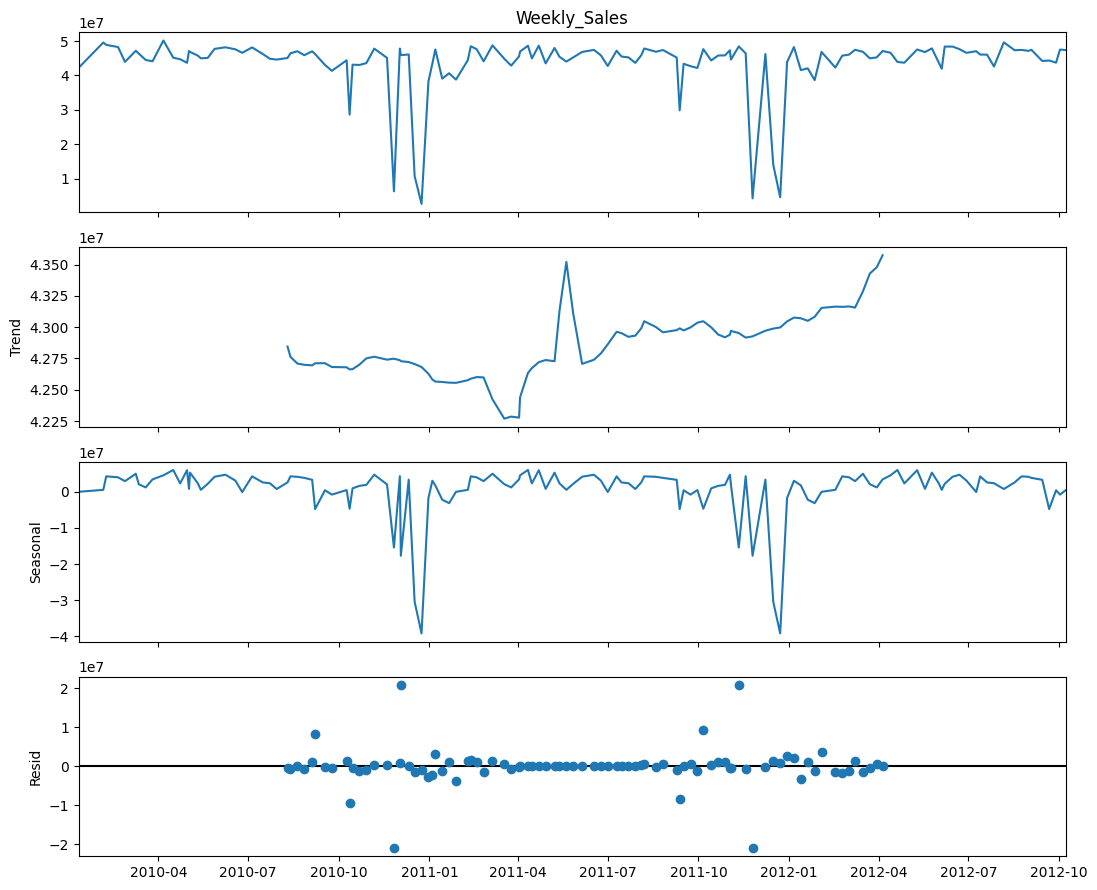

In [350]:
weekly_sales = train_df.groupby('Date')['Weekly_Sales'].sum()

rcParams['figure.figsize'] = 11, 9

decompose = seasonal_decompose(weekly_sales, model='additive', period=52)
decompose.plot()

plt.show()

Проведем тест Дики-Фуллера для оценки стационарности рядов по каждому магазину

In [351]:
grouped = train_df.groupby('Store')

def adf_test(series):
    result = adfuller(series)
    return result[1]

adf_results = grouped['Weekly_Sales'].apply(adf_test)

non_stationary_stores = adf_results[adf_results > 0.05]

print(non_stationary_stores)

Store
3     0.530719
4     0.623952
13    0.487663
14    0.703129
25    0.120598
26    0.099810
31    0.549622
35    0.394365
36    0.758448
38    0.866352
39    0.081233
41    0.525239
43    0.260087
44    0.927145
Name: Weekly_Sales, dtype: float64


Критерий Дики-Фуллера не отвергает гипотезу о нестационарности рядов. Сделаем дифференцирование и снова посмотрим на стационарность рядов

In [352]:
def differentiate_with_shift_inplace(df, shift=1):
    df['Diff_Weekly_Sales'] = df.groupby('Store')['Weekly_Sales'].transform(lambda x: x - x.shift(shift))

differentiate_with_shift_inplace(train_df, shift=1)

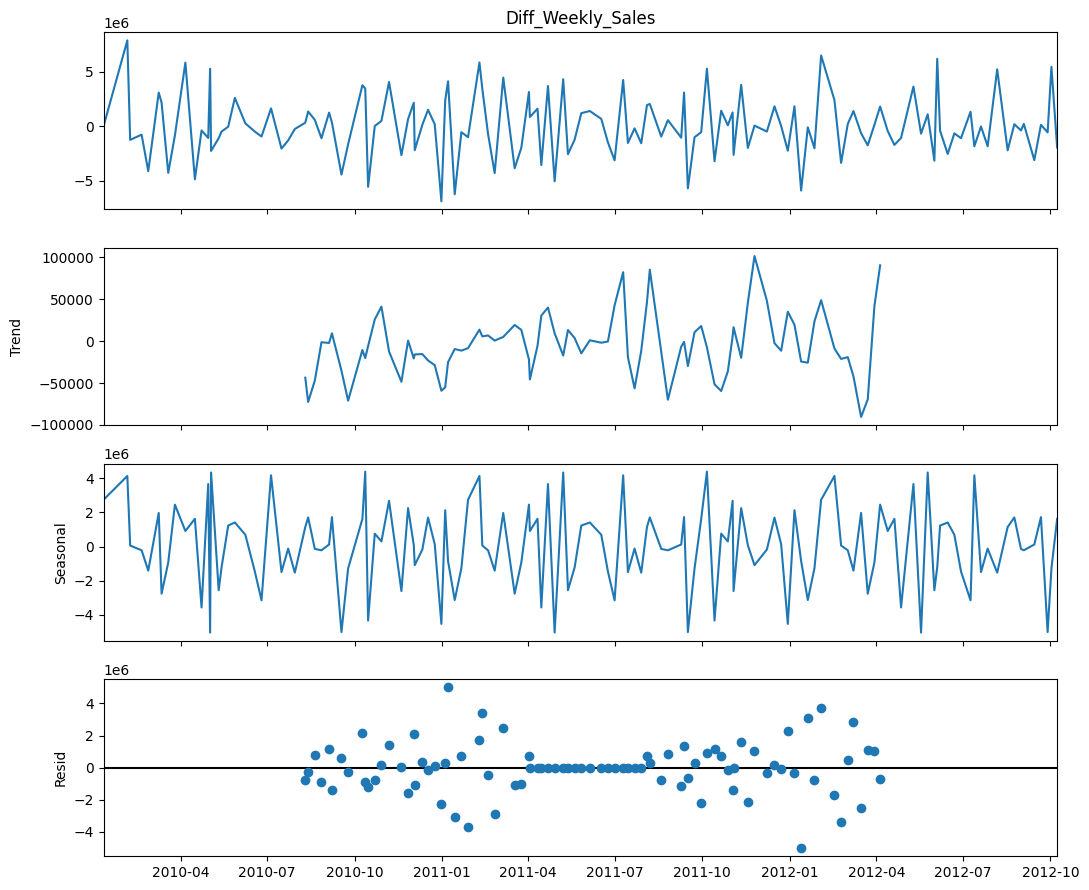

Series([], Name: Diff_Weekly_Sales, dtype: float64)


In [353]:
weekly_sales = train_df.groupby('Date')['Diff_Weekly_Sales'].apply(lambda x: x.iloc[1:].sum())
rcParams['figure.figsize'] = 11, 9

decompose = seasonal_decompose(weekly_sales, model='additive', period=52)
decompose.plot()

plt.show()

grouped = train_df.groupby('Store')

def adf_test(series):
    result = adfuller(series)
    return result[1]

adf_results = grouped['Diff_Weekly_Sales'].apply(lambda x: adf_test(x[1:]))

non_stationary_stores = adf_results[adf_results > 0.05]

print(non_stationary_stores)

Получаем, что тренд отсутствует и критерий Дики-Фуллера полностью отвергает гипотезу о нестационарности. Значит ряды стационарны

# Подбор модели

## Хольт-Винтерс

Попробуем использовать модель Хольта-Винтерса для прогнозирования

In [354]:
stores = train_df['Store'].unique()

seasonal_period = 12

all_pred = []
all_true_val = []
hw_models = {}

for store_id in stores:
    store_data = train_df[train_df['Store'] == store_id]['Weekly_Sales']

    train = store_data[:int(0.8 * len(store_data))]
    test = store_data[int(0.8 * len(store_data)):]

    hw_model = ExponentialSmoothing(train, trend="add", seasonal="add", seasonal_periods=seasonal_period)
    hw_fit = hw_model.fit()
    
    hw_models[store_id] = hw_fit
    
    hw_forecast = hw_fit.forecast(steps=len(test))
    
    
    all_pred.extend(hw_forecast)
    all_true_val.extend(test)
    
    hw_mape = mean_absolute_percentage_error(test, hw_forecast)
    
    # графики
    # plt.figure(figsize=(12, 6))
    # plt.plot(train.index, train, label='Train', color='blue')
    # plt.plot(test.index, test, label='Test', color='green')
    # plt.plot(test.index, hw_forecast, label='Holt-Winters Forecast', color='orange')
    # plt.title(f"Store {store_id} - Mean Absolute Percentage Error: {hw_mape}")
    # plt.xlabel("Date")
    # plt.ylabel("Weekly Sales")
    # plt.grid(True)
    # plt.legend(loc='upper left')
    # plt.show()

hw_mape = mean_absolute_percentage_error(all_pred, all_true_val)
print(f"MAPE: {hw_mape}")

MAPE: 0.0735621638409279


## Линейная регрессия

Также посторим модель линейной регрессии 

In [355]:
features = ['Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'Weekday', 'Month', 'Year', 'Season']

In [356]:
all_y_true = []
all_y_pred = []
models = {} 

for store_id in train_df['Store'].unique():

    store_data = train_df[train_df['Store'] == store_id]
    
    X = store_data[features]
    y = store_data['Weekly_Sales']
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

    model = LinearRegression()
    model.fit(X_train, y_train)
    
    models[store_id] = model
    
    y_pred = model.predict(X_test)

    all_y_true.extend(y_test)
    all_y_pred.extend(y_pred)
    
    # графики
    # y_pred_full = np.concatenate([y_train.values, y_pred])
    # y_test_full = np.concatenate([y_train.values, y_test.values])
    # plt.figure(figsize=(15, 7))
    # plt.plot(y_pred_full, "r", label="Prediction")
    # plt.plot(y_test_full, label="Test")
    # plt.plot(y_train.values, label="Train")
    # plt.legend(loc="best")
    # plt.title(f"Store {store_id} - Mean Absolute Percentage Error: {mean_absolute_percentage_error(y_pred, y_test)}")
    # plt.grid(True)
    # plt.show()

mape = mean_absolute_percentage_error(all_y_true, all_y_pred)
print(f"MAPE: {mape}")

MAPE: 0.05591175303554681


# Submit

Линейная регрессия показа результат лучше, поэтому будем использовать её

Прогнозируем, используя линейную регрессию

In [357]:
predictions = []

for store_id, store_data in test_df.groupby('Store'):
    model = models.get(store_id)
    X = store_data[features]
    y = model.predict(X)
    predictions.extend(y)

data = {
    "Weekly_Sales": predictions
}
submit = pd.DataFrame(data)
submit.to_csv('submission.csv', index_label="ID")

Прогнозируем, используя модель Хольта-Винтерса

In [358]:
# predictions = []

# for store_id, store_data in test_df.groupby('Store'):
#     model = hw_models.get(store_id)
#     forecast = model.forecast(steps=len(store_data))
    
#     predictions.extend(forecast)

# data = {
#     "Weekly_Sales": predictions
# }
# submit = pd.DataFrame(data)
# submit.to_csv('submission.csv', index_label="ID")